# Testing Reflection and Mutual Coupling Systematics Injection

Validation notebook: compares clean visibilities against corrupted visibilities
(FG + EoR + injected cable reflections and cross-coupling systematics).

## Imports

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy import constants, units
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs

import hera_sim
if hera_sim.__version__.startswith('0'):
    from hera_sim.rfi import _listify
else:
    from hera_sim.utils import _listify

plt.rcParams.update({'font.size': 14})

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Load Data

All arrays are loaded from `res/npy_data/` relative to the repo root.

| File | Shape | Description |
|---|---|---|
| `fg_true.npy` | (203, 120) | Foreground-only visibility [Jy] |
| `eor_true.npy` | (203, 120) | EoR-only visibility [Jy] |
| `vis_corrupted.npy` | (203, 120) | FG + EoR + injected systematics [Jy] |
| `freqs_full.npy` | (120,) | Frequency array [Hz] |
| `lsts_full.npy` | (203,) | LST array [radians] |

In [2]:
from pyuvdata import UVData
uvd = UVData()
uvd.read_uvh5('../../res/test_data/vis-eor-ptsrc-gsm.uvh5', read_data=True)
times = np.unique(uvd.time_array)

In [3]:
DATA_DIR = Path('../../res/npy_data')

vis_fg       = np.load(DATA_DIR / 'fg_true.npy')
vis_eor      = np.load(DATA_DIR / 'eor_true.npy')
vis_fg_eor   = vis_eor + vis_fg

freqs        = np.load(DATA_DIR / 'freqs_full.npy')       # Hz
lsts         = np.load(DATA_DIR / 'lsts_full.npy')       # radians

print(f'vis_fg_eor:    {vis_fg_eor.shape}  dtype={vis_fg_eor.dtype}')
print(f'freqs:         {freqs.shape}  [{freqs[0]/1e6:.1f} – {freqs[-1]/1e6:.1f} MHz]')
print(f'lsts:          {lsts.shape}  [{lsts[0]:.3f} – {lsts[-1]:.3f} rad]')

vis_fg_eor:    (203, 120)  dtype=complex128
freqs:         (120,)  [100.0 – 120.2 MHz]
lsts:          (203,)  [1.047 – 1.636 rad]


In [4]:
import yaml

cfg_file = "sim_config.yaml"
with open(cfg_file, "r") as cfg:
    config = yaml.load(cfg, Loader=yaml.SafeLoader)  # Specify SafeLoader explicitly
_ = config.pop("noise")
_ = config.pop("gains")

## Convenience Function: `plot_waterfalls`

Produces a 2×2 grid of waterfall plots: freq–time, freq–fringe-rate, delay–time, delay–fringe-rate.

In [5]:
def plot_waterfalls(data, freqs, times, windows=None, mode='log',
                    cmap='inferno', dynamic_range=None, limit_drng='all',
                    baseline=None, horizon_color='magenta', plot_limits=None,
                    freq_window_kwargs=None, time_window_kwargs=None):
    """
    2x2 waterfall grid: freq-time | freq-fringe-rate / delay-time | delay-fringe-rate.

    Parameters
    ----------
    data : ndarray, shape (NTIMES, NFREQS)
    freqs : ndarray, shape (NFREQS,)  [Hz]
    times : ndarray, shape (NTIMES,)  [JD]
    windows : str or length-1/2 tuple of str
        Taper for fringe-rate (axis 0) and delay (axis 1) transforms.
        If length 2, first entry is time taper, second is freq taper.
    dynamic_range : float
        Orders of magnitude for colormap range (log mode only).
    limit_drng : str or tuple of str
        Which axes to apply dynamic_range to. Options: 'freq','time','delay','fringe_rate','all'.
    baseline : float or array-like
        Baseline length [m] for horizon overplot in delay panels.
    plot_limits : dict
        Axis limits; keys from ('freq','time','delay','fringe_rate').
        Delay in ns, fringe_rate in mHz, freq in Hz, time in JD.

    Returns
    -------
    fig, data_fr_dly
    """
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}

    if windows is not None:
        if type(windows) not in (str, list, tuple):
            raise ValueError("windows must be a string, tuple, or list.")
        if len(_listify(windows)) > 2:
            raise ValueError("Only up to two windows may be specified.")
        if len(_listify(windows)) == 2:
            time_window = gen_window(windows[0], times.size, **time_window_kwargs)
            freq_window = gen_window(windows[1], freqs.size, **freq_window_kwargs)
        else:
            if not isinstance(windows, str):
                windows = windows[0]
            time_window = gen_window(windows, times.size, **time_window_kwargs)
            freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)
    else:
        time_window = gen_window(None, times.size, **time_window_kwargs)
        freq_window = gen_window(None, freqs.size, **freq_window_kwargs)

    time_window = time_window[:, None]
    freq_window = freq_window[None, :]

    data_fr     = FFT(data * time_window, axis=0)
    data_dly    = FFT(data * freq_window, axis=1)
    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)

    fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3  # mHz
    dlys         = fourier_freqs(freqs) * 1e9                       # ns
    plot_freqs   = freqs / 1e6                                       # MHz
    jd           = int(np.floor(times[0]))
    plot_times   = times - jd

    if baseline is not None:
        horizon = np.linalg.norm(baseline) / constants.c.value * 1e9  # ns

    fig  = plt.figure(figsize=(14, 10))
    axes = fig.subplots(2, 2)

    for j, ax in enumerate(axes.ravel()):
        column = j % 2
        row    = j // 2
        xlabel = "Frequency [MHz]" if row == 0 else "Delay [ns]"
        ylabel = ("Time Since JD%d [days]" % jd) if column == 0 else "Fringe Rate [mHz]"
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)

        if column == 0 and row == 0:
            use_data  = data
            extent    = (plot_freqs.min(), plot_freqs.max(), plot_times.max(), plot_times.min())
            vis_label = r"$\log_{10}|V(\nu, t)|$ [Jy]"
            xlimits   = plot_limits.get("freq",        extent[:2]) if plot_limits else extent[:2]
            ylimits   = plot_limits.get("time",        extent[2:]) if plot_limits else extent[2:]
        elif column == 0 and row == 1:
            use_data  = data_dly
            extent    = (dlys.min(), dlys.max(), plot_times.max(), plot_times.min())
            vis_label = r"$\log_{10}|\tilde{V}(\tau, t)|$ [Jy Hz]"
            xlimits   = plot_limits.get("delay",       extent[:2]) if plot_limits else extent[:2]
            ylimits   = plot_limits.get("time",        extent[2:]) if plot_limits else extent[2:]
        elif column == 1 and row == 0:
            use_data  = data_fr
            extent    = (plot_freqs.min(), plot_freqs.max(), fringe_rates.max(), fringe_rates.min())
            vis_label = r"$\log_{10}|\tilde{V}(\nu, f)|$ [Jy s]"
            xlimits   = plot_limits.get("freq",        extent[:2]) if plot_limits else extent[:2]
            ylimits   = plot_limits.get("fringe_rate", extent[2:]) if plot_limits else extent[2:]
        else:
            use_data  = data_fr_dly
            extent    = (dlys.min(), dlys.max(), fringe_rates.max(), fringe_rates.min())
            vis_label = r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]"
            xlimits   = plot_limits.get("delay",       extent[:2]) if plot_limits else extent[:2]
            ylimits   = plot_limits.get("fringe_rate", extent[2:]) if plot_limits else extent[2:]

        if limit_drng == 'all':
            limit_drng = ("freq", "time", "delay", "fringe_rate")

        clip_drng = (
            ("time"        in limit_drng and column == 0) or
            ("freq"        in limit_drng and row    == 0) or
            ("delay"       in limit_drng and row    == 1) or
            ("fringe_rate" in limit_drng and column == 1)
        )

        if dynamic_range is not None and mode == 'log' and clip_drng:
            vmax = np.log10(np.abs(use_data)).max()
            vmin = vmax - dynamic_range
        else:
            vmin, vmax = None, None

        cbar_label = vis_label if mode == 'log' else "Phase [rad]"
        fig.sca(ax)
        cax = waterfall(use_data, extent=extent, mode=mode, vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlim(xlimits)
        ax.set_ylim(ylimits)
        if baseline is not None and row == 1:
            ax.axvline( horizon, color=horizon_color, ls='--')
            ax.axvline(-horizon, color=horizon_color, ls='--')
        fig.colorbar(cax, label=cbar_label)

    return fig, data_fr_dly

## Plot Settings

In [6]:
time_taper  = 'blackman-harris'
freq_taper  = 'blackman-harris'
plot_limits = {"delay": (-2900, 2900), "fringe_rate": (12, -12)}
wfall_kw    = dict(
    windows=(time_taper, freq_taper),
    dynamic_range=5,
    limit_drng=("delay", "fringe_rate"),
    horizon_color="dodgerblue",
    cmap='inferno',
    plot_limits=plot_limits,
)

## Clean Visibility: FG + EoR

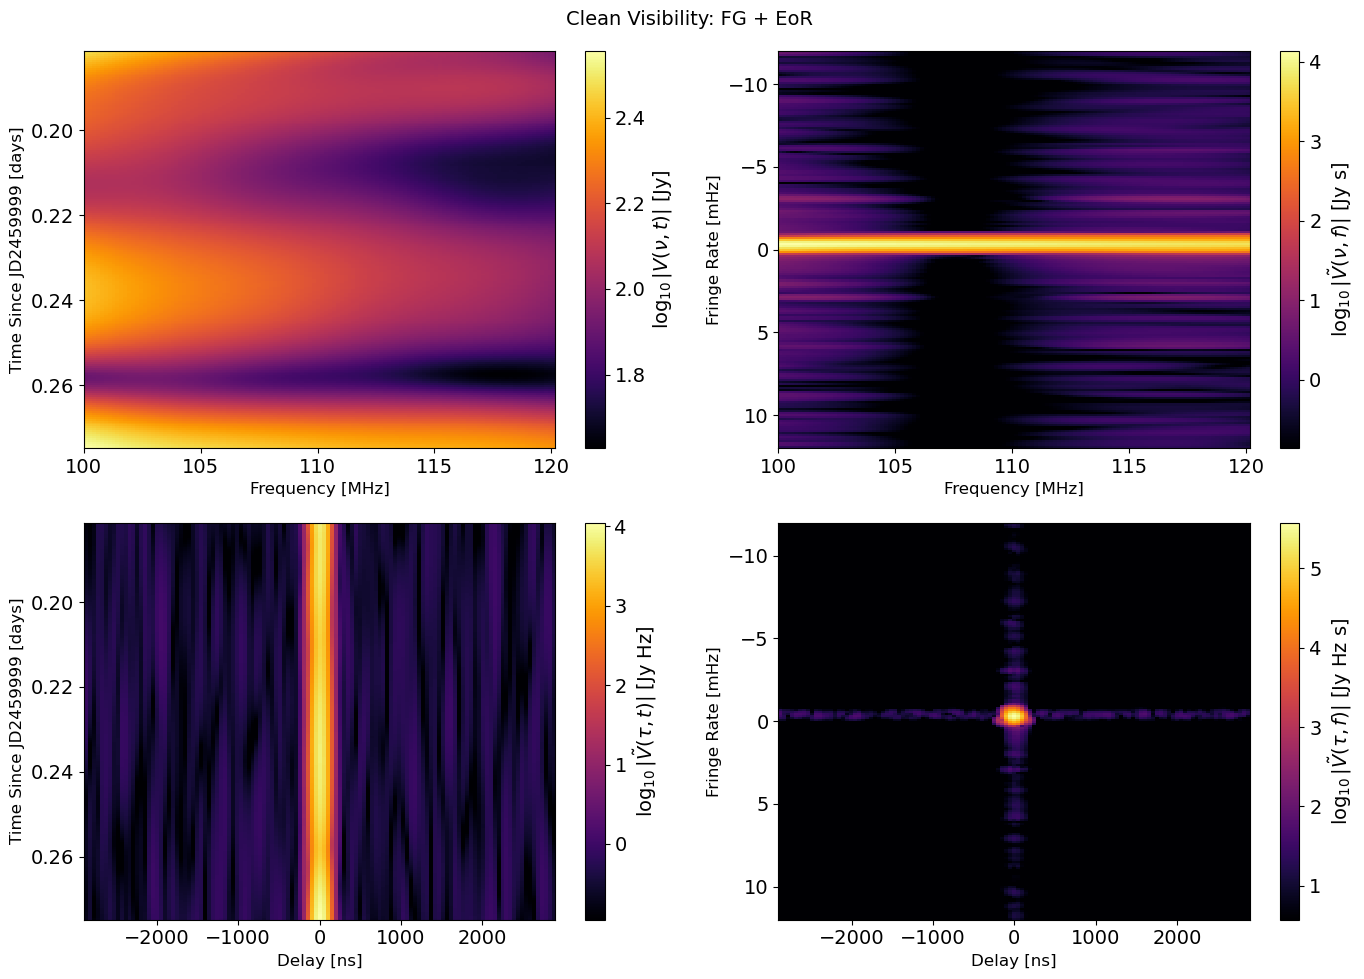

In [7]:
fig, data_clean = plot_waterfalls(vis_fg_eor, freqs, times, **wfall_kw)
fig.suptitle("Clean Visibility: FG + EoR", fontsize=14)
fig.tight_layout()

## Corrupted Visibility: FG + EoR + Systematics

In [14]:
import copy
import types

sim = copy.deepcopy(uvd)

if not hasattr(sim, "telescope"):
    sim.telescope = types.SimpleNamespace(
        antenna_numbers   = uvd.antenna_numbers,
        antenna_positions = uvd.antenna_positions,
        name              = uvd.telescope_name,
        location          = uvd.telescope_location,
    )

Nbls  = uvd.Nbls   # 9
Npols = uvd.data_array.shape[-1]

# Tile vis_fg_eor across all baselines: (203,120) -> (1827,120)
vis_tiled = np.tile(vis_fg_eor, (Nbls, 1))   # (1827, 120)

if uvd.data_array.ndim == 4:
    # pyuvdata 2.x: (Nblts, 1, Nfreqs, Npols)
    sim.data_array = np.repeat(
        vis_tiled[:, np.newaxis, :, np.newaxis], Npols, axis=-1
    ).astype(complex)
else:
    # pyuvdata 3.x: (Nblts, Nfreqs, Npols)
    sim.data_array = np.repeat(
        vis_tiled[:, :, np.newaxis], Npols, axis=-1
    ).astype(complex)

print("data_array shape:", sim.data_array.shape)  # should be (1827, 1, 120, Npols)
print("expected shape:  ", uvd.data_array.shape)

corrupt, systematics, params = apply_systematics(copy.deepcopy(sim), **config)

data_array shape: (1827, 120, 4)
expected shape:   (1827, 120, 4)


NameError: name 'apply_systematics' is not defined

In [ ]:
# Get indices for a specific baseline, e.g. the first one
ant1, ant2 = uvd.get_antpairs()[0]
blt_inds = np.where(
    (corrupt.ant_1_array == ant1) & (corrupt.ant_2_array == ant2)
)[0]

vis_corrupted = corrupt.data_array[blt_inds, 0, :, 0]  # (203, 120)

NameError: name 'corrupt' is not defined

In [11]:
import numpy as np

def inject_cable_reflections(
    vis,
    freqs,
    amp=1e-3,
    delays_ns=(-1200, 1200),
    seed=None,
):
    rng = np.random.default_rng(seed)
    freqs_GHz = freqs / 1e9

    # One shared phase per delay — same for both antennas
    # g1 * conj(g2) = |g|^2 = real, symmetric in delay space
    g = np.ones(len(freqs_GHz), dtype=complex)
    for dly in delays_ns:
        phs = rng.uniform(0, 2 * np.pi)   # shared phase
        g += amp * np.exp(2j * np.pi * freqs_GHz * dly + 1j * phs)

    # |g|^2 is real, gives symmetric spikes at +/-1200 ns
    baseline_gain = g * np.conj(g)                         # (Nfreqs,) real
    vis_corrupted = vis * baseline_gain[np.newaxis, :]     # (Ntimes, Nfreqs)

    return vis_corrupted, {"g": g, "baseline_gain": baseline_gain}


# --- Usage ---
vis_corrupted, gains = inject_cable_reflections(
    vis       = vis_fg_eor,   # (203, 120)
    freqs     = freqs,
    amp       = 1e-3,
    delays_ns = (-1200, 1200),
    seed      = 42,
)

print("Input shape: ", vis_fg_eor.shape)
print("Output shape:", vis_corrupted.shape)

'''
The key physics is:
```
V_out(t, f) = V_in(t, f) · g₁(f) · g₂*(f)

where  gₙ(f) = 1 + amp · exp(2πi · f[GHz] · τ[ns] + iφₙ)
'''

Input shape:  (203, 120)
Output shape: (203, 120)


'\nThe key physics is:\n```\nV_out(t, f) = V_in(t, f) · g₁(f) · g₂*(f)\n\nwhere  gₙ(f) = 1 + amp · exp(2πi · f[GHz] · τ[ns] + iφₙ)\n'

## Injected Systematics (Corrupted − Clean)

In [12]:
import sys
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import ImageGrid

sys.path.append('../../../plots-hydra-pspec/plotting_codes')
from plotting_functions import plot_waterfalls,plot_waterfalls_from_dlfr

dynamic_range = 5
paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#EEF4ED-BC7C95-89043D
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

noise=np.load('../../../hydra-pspec-systematic/res/test_data/noise.npy')

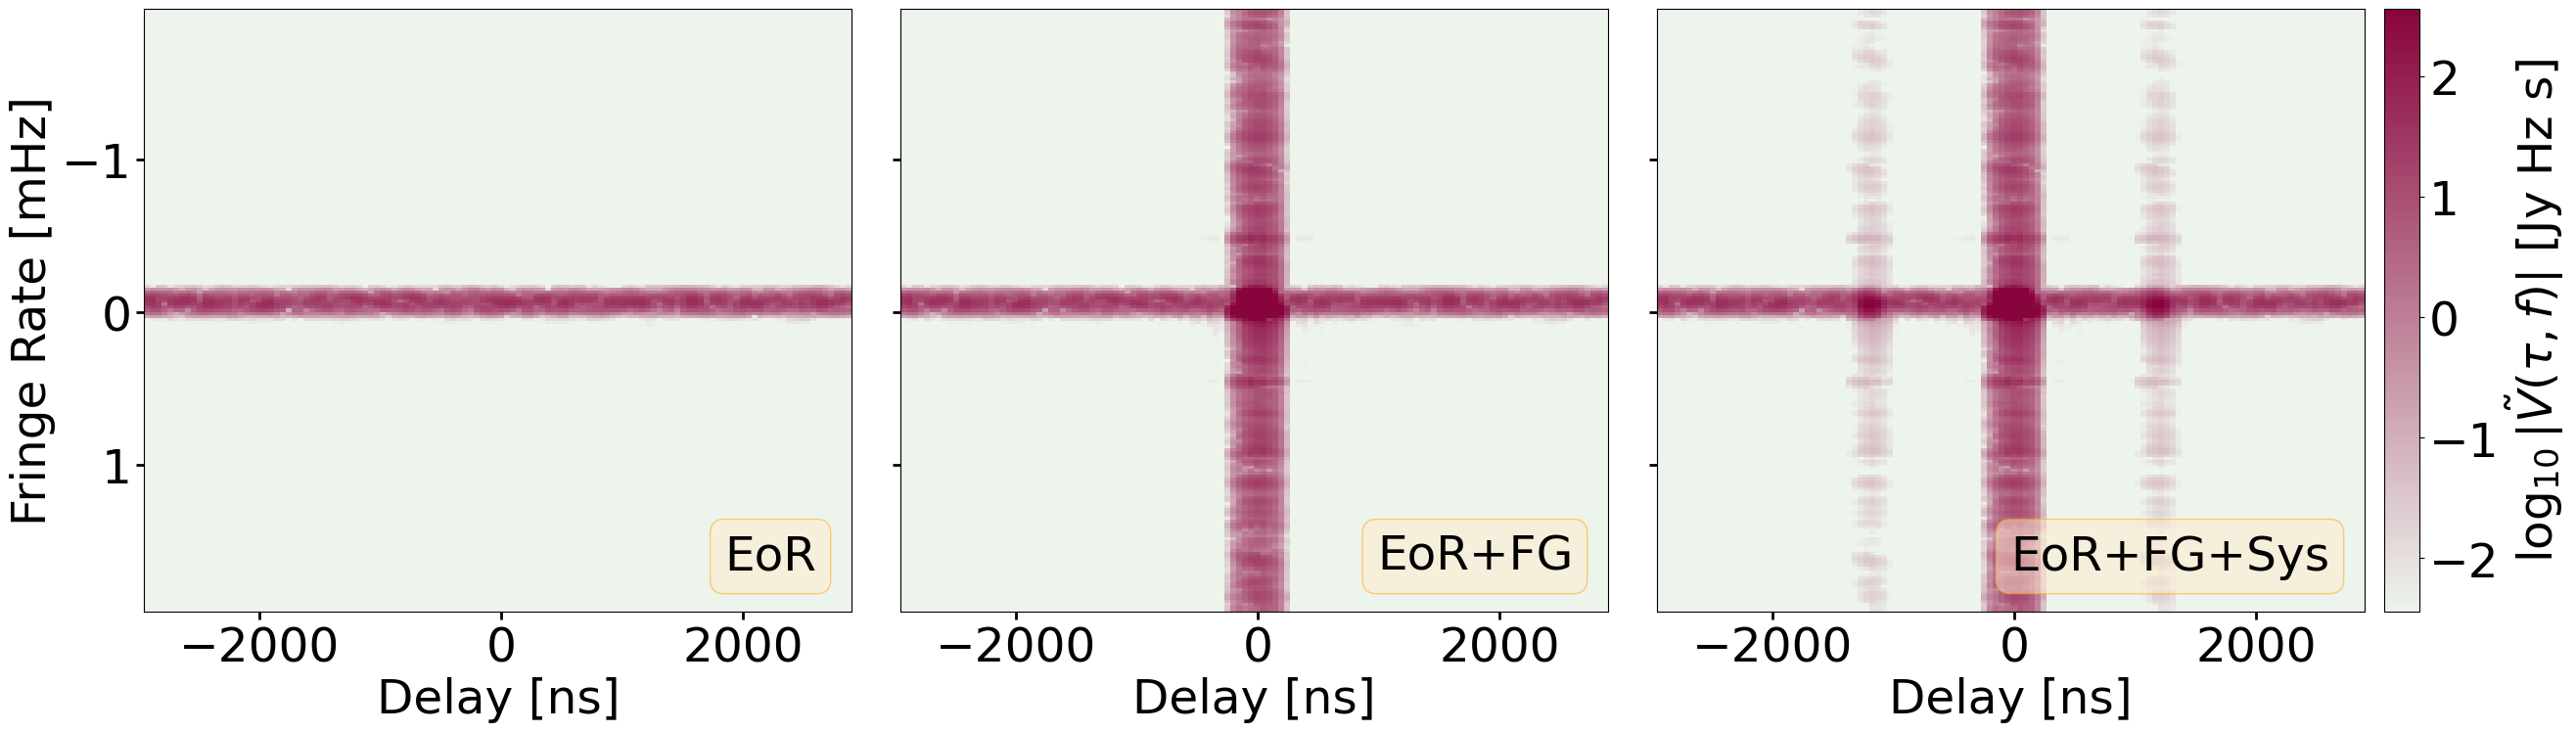

In [13]:
'''USE THIS'''
dynamic_range = 5
plt.rcParams.update({'font.size': 35})
# Global vmax across all three datasets
vmax = max(
    np.log10(np.abs(vis_eor)).max(),
    np.log10(np.abs(vis_fg_eor)).max(),
    np.log10(np.abs(vis_corrupted)).max()
)
vmin = vmax - dynamic_range

fig = plt.figure(figsize=(30, 8))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location="right",
    cbar_mode="single",        # one shared colorbar
    cbar_size="5%",
    cbar_pad=0.2,
    aspect=False
)

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)

eor_dlfr = plot_waterfalls(vis_eor, freqs, lsts, windows='blackman-harris', fig=fig, ax=ax[0],
                mode='log', cmap=paper_map_pink, vmin=vmin, vmax=vmax,  # explicit
                dynamic_range=None,                                       # disable internal recalc
                limit_drng='all', colorbar_flag=False,
                baseline=None, horizon_color='magenta')
ax[0].text(0.95, 0.07, 'EoR', bbox=bbox,
           transform=ax[0].transAxes, horizontalalignment='right')

sky_dlfr = plot_waterfalls(vis_fg_eor, freqs, lsts, windows='blackman-harris', fig=fig, ax=ax[1],
                mode='log', cmap=paper_map_pink, vmin=vmin, vmax=vmax,
                dynamic_range=None, limit_drng='all', colorbar_flag=False,
                baseline=None, horizon_color='magenta')
ax[1].text(0.95, 0.07, 'EoR+FG', bbox=bbox,
           transform=ax[1].transAxes, horizontalalignment='right')

crosscorr_dlfr = plot_waterfalls(vis_corrupted, freqs, lsts, windows='blackman-harris', fig=fig, ax=ax[2],
                mode='log', cmap=paper_map_pink, vmin=vmin, vmax=vmax,
                dynamic_range=None, limit_drng='all', colorbar_flag=False,
                baseline=None, horizon_color='magenta')
ax[2].text(0.95, 0.07, 'EoR+FG+Sys', bbox=bbox,
           transform=ax[2].transAxes, horizontalalignment='right')

# Single unified colorbar
sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=paper_map_pink)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax.cbar_axes[0])
cbar.set_label(r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]", c='black')
cbar.ax.tick_params(axis='y', which='both', color='black', labelcolor='black')

plt.savefig('/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'+'/'+'data_in_dlfr_space.pdf',bbox_inches='tight',dpi=300)